In [1]:
from scipy.interpolate import RectBivariateSpline, interp1d
import numpy as np

import os
import matplotlib.pyplot as plt
# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

from matplotlib import rc
rc('text', usetex=True)
rc('font',**{'family':'serif','serif':['Times']})

plt.rc('mathtext', fontset='stix')
plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=18)

In [2]:
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.cosmology.MGrowth_cosmology import MGrowthLinearPerturbations

/Users/s2265800/miniforge3/envs/cloe-org-env-v2026.1/lib/python3.12/site-packages/HMcode2020Emu
Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


## Let's see how $\mu$ behaves on different scales

In [3]:
omega0=0.31
k = np.logspace(-3, 1, 128)

a=1.
w0=-1.
wa=0.
omegaL = (1.-omega0) * a**(-3.*(1.+w0+wa)) * np.exp(3.*(-1.+a)*wa)
omegaL0 = (1.-omega0) 
E = np.sqrt(omega0/a**3 + omegaL)
h0 = 1./2997.92458

def mu_DE_a_cloe(a, mu0, c1, lamb):
    omegaL = (1.-omega0) * a**(-3.*(1.+w0+wa)) * np.exp(3.*(-1.+a)*wa)
    omegaL0 = (1.-omega0) 
    E = np.sqrt(omega0/a**3 + omegaL)
    return 1. + mu0*(omegaL/E**2)/omegaL0*((1+c1*(lamb*E/k)**2)/(1.+(lamb*E/k)**2))

def mu_DE_a_desi(a, mu0, c1, lamb):
    omegaL = (1.-omega0) * a**(-3.*(1.+w0+wa)) * np.exp(3.*(-1.+a)*wa)
    omegaL0 = (1.-omega0) 
    E = np.sqrt(omega0/a**3 + omegaL)
    return 1. + mu0*(omegaL/E**2)/omegaL0*((1+c1*h0*(lamb*E/k)**2)/(1.+(lamb*h0*E/k)**2))

(0.001, 10)

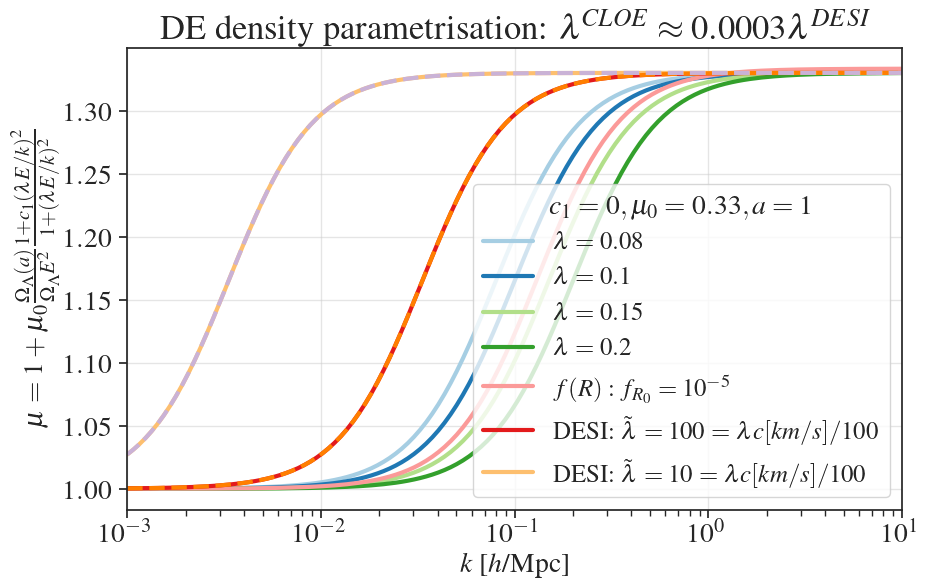

In [4]:
c1 = 0.0
var1 = (k/a)**2
h0 = 1./2997.92458
fR0 = 10**(-5.)
mu_fofR = 1. + var1/(3.*(var1+(omega0/a**3-4.*(omega0-1.))**3/(2.*fR0/h0**2*(4.-3.*omega0)**2)));
fig, ax = plt.subplots(figsize=(10, 6), facecolor='w', sharex=True, sharey=True)
ax.semilogx(k, mu_DE_a_cloe(1, 0.33, 0.0, 0.08), label='$\\lambda=0.08$')
ax.semilogx(k, mu_DE_a_cloe(1, 0.33, 0.0,0.1), label='$\\lambda=0.1$')
ax.semilogx(k, mu_DE_a_cloe(1, 0.33, 0.0,0.15), label='$\\lambda=0.15$')
ax.semilogx(k, mu_DE_a_cloe(1, 0.33, 0.0, 0.2), label='$\\lambda=0.2$')
ax.semilogx(k, mu_fofR, label='$f(R): f_{R_0}=10^{-5}$')
ax.semilogx(k, mu_DE_a_desi(1, 0.33, 0.0, 100), label='DESI: $\\tilde{\\lambda}=100=\\lambda c[km/s]/100$')
ax.semilogx(k, mu_DE_a_desi(1, 0.33, 0.0, 10), label='DESI: $\\tilde{\\lambda}=10=\\lambda c[km/s]/100$')
ax.semilogx(k, mu_DE_a_cloe(1, 0.33, 0.0, 100*h0),linestyle='--')
ax.semilogx(k, mu_DE_a_cloe(1, 0.33, 0.0, 10*h0),linestyle='--')
ax.legend(title='$c_1=0, \\mu_0=0.33, a=1$', title_fontsize=20)
ax.set_xlabel('$k$ [$h$/Mpc]')
ax.set_ylabel('$\\mu=1+\\mu_0\\frac{\\Omega_\\Lambda(a)}{\\Omega_\\Lambda E^2}\\frac{1+c_1(\\lambda E/k)^2}{1+(\\lambda E/k)^2}$')
ax.set_title(f'DE density parametrisation: $\\lambda^{{CLOE}} \\approx {round(h0, 4)} \\lambda^{{DESI}}$')
ax.grid(alpha=0.5)
ax.set_xlim(0.001, 10)

(0.001, 10)

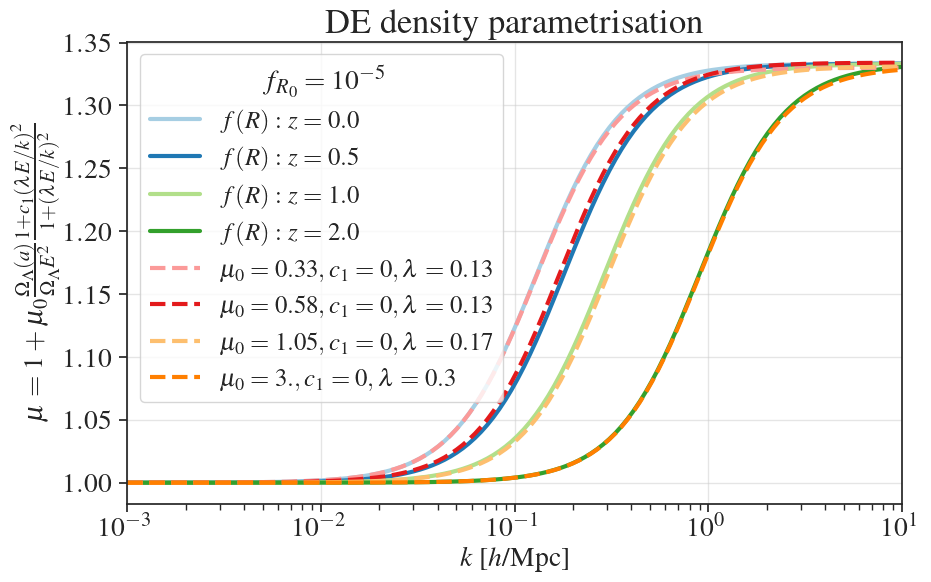

In [5]:
zz = np.array([0., 0.5, 1., 2.])
aa = 1./(1.+zz)
var1 = (k/a)**2
h0 = 1./2997.92458
fR0 = 10**(-5.)
mu_fofR = lambda a_i: 1. + 1./3*var1/(var1+(omega0/a_i**3-4.*(omega0-1.))**3/(2.*fR0/h0**2*(4.-3.*omega0)**2))
fig, ax = plt.subplots(figsize=(10, 6), facecolor='w', sharex=True, sharey=True)
for i in range(len(aa)):
    ax.semilogx(k, mu_fofR(aa[i]), label='$f(R): z={:.1f}$'.format(zz[i]))
ax.semilogx(k, mu_DE_a_cloe(aa[0], 0.33, 0.0, 0.13), label='$\\mu_0=0.33, c_1=0, \\lambda=0.13$', linestyle='--')
ax.semilogx(k, mu_DE_a_cloe(aa[1], 0.58, 0.0, 0.13), label='$\\mu_0=0.58, c_1=0, \\lambda=0.13$', linestyle='--')
ax.semilogx(k, mu_DE_a_cloe(aa[2], 1.05, 0.0, 0.17), label='$\\mu_0=1.05, c_1=0, \\lambda=0.17$', linestyle='--')
ax.semilogx(k, mu_DE_a_cloe(aa[3], 3., 0.0, 0.3), label='$\\mu_0=3., c_1=0, \\lambda=0.3$', linestyle='--')
ax.legend(title='$f_{R_0}=10^{-5}$', title_fontsize=20)
ax.set_xlabel('$k$ [$h$/Mpc]')
ax.set_ylabel('$\\mu=1+\\mu_0\\frac{\\Omega_\\Lambda(a)}{\\Omega_\\Lambda E^2}\\frac{1+c_1(\\lambda E/k)^2}{1+(\\lambda E/k)^2}$')
ax.set_title('DE density parametrisation')
ax.grid(alpha=0.5)
ax.set_xlim(0.001, 10)

## Let's compare different tools on linear scales

In [ ]:
zs = np.linspace(1e-4, 3, 100)

# The arguments of the Background functions follow the cosmology.API
background = CAMBBackground(H0=67.0, 
                            Omega_cdm0=0.27, 
                            Omega_b0=0.049, 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2.1e-9,
                            mnu = 0.0001,
                            gamma_MG = 0.545,
                            N_mnu = 1)
linear_perturbations_emu = HMemuLinearPerturbations(background, zs)

mgpars_example = {
    'mu0': 0.33,
    'sigma0': 0.,
    'c1': 0.,
    'c2': 0.,
    'lam': 0.08,
    'q1': 0.,
    'q2': 0.,
    'q3': 0.
}


linear_perturbations_mu = MGrowthLinearPerturbations(background, linear_perturbations_emu,
                                                     gravity_model='musigma-de',
                                                     mgpars=mgpars_example 
                                                     )
linear_perturbations_mu_scaledep = MGrowthLinearPerturbations(background, linear_perturbations_emu,
                                                     gravity_model='mu',
                                                     mgpars=mgpars_example 
                                                     )
                                                    

In [7]:
print(linear_perturbations_emu.sigma8_0())
print(linear_perturbations_mu.sigma8_0())
print(linear_perturbations_mu_scaledep.sigma8_0())

0.8280027109334782
0.8625426101221221
1.3878724074967135


In [16]:
from cloelib.cosmology.ReACTEmu_cosmology import MGemuNonlinearBoost
react_emu = MGemuNonlinearBoost(background, linear_perturbations_emu, zs, gravity_model='mu', mgpars=mgpars_example)

/Users/s2265800/miniforge3/envs/cloe-org-env-v2026.1/lib/python3.12/site-packages/MGEmu
Loading nonlinear emulator...
Nonlinear emulator loaded in memory.


In [17]:
ks = np.logspace(np.log10(1e-3), np.log10(6), 100)
ps_lcdm = linear_perturbations_emu.matter_power_spectrum(0, ks)
ps_mu = linear_perturbations_mu.matter_power_spectrum(0, ks)
ps_mu_scaledep = linear_perturbations_mu_scaledep.matter_power_spectrum(0, ks)
react_boost = react_emu.MGboost_interp(0, ks)

Text(0.5, 1.0, 'Ratio')

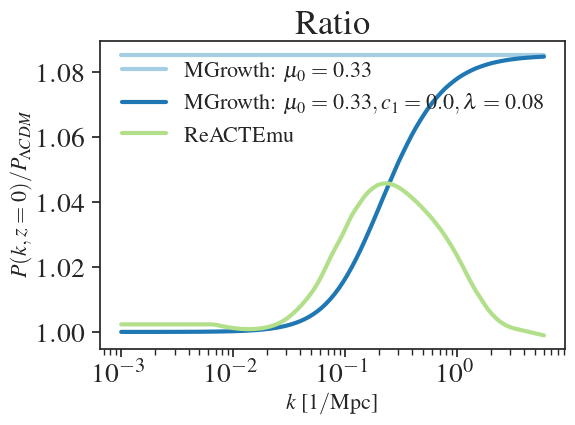

In [21]:
# Create the figure
plt.figure(figsize=(6, 4))
plt.semilogx(ks, ps_mu/ps_lcdm, label=f"MGrowth: $\\mu_0={mgpars_example['mu0']}$")
plt.semilogx(ks, ps_mu_scaledep/ps_lcdm, label=f"MGrowth: $\\mu_0={mgpars_example['mu0']}, c_1={mgpars_example['c1']}, \\lambda={mgpars_example['lam']}$")
plt.semilogx(ks, react_boost[0], label='ReACTEmu')
plt.xlabel('$k$ [$1/$Mpc]', fontsize = 16)
plt.ylabel('$P(k, z=0)/P_{\\Lambda CDM}$', fontsize = 16)
plt.legend(fontsize = 16, loc='upper right', frameon=False)
plt.title("Ratio")